In [158]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [159]:
data_Admission = pd.read_csv('/content/Admission_Predict.csv')


In [160]:
data_Admission_linear = pd.read_csv('/content/Admission_Predict.csv')

In [161]:
data_Admission.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [162]:
data_Admission.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,200.500000,316.807500,107.410000,3.087500,3.400000,3.452500,8.598925,0.547500,0.724350
std,115.614301,11.473646,6.069514,1.143728,1.006869,0.898478,0.596317,0.498362,0.142609
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.000000,6.800000,0.000000,0.340000
25%,100.750000,308.000000,103.000000,2.000000,2.500000,3.000000,8.170000,0.000000,0.640000
50%,200.500000,317.000000,107.000000,3.000000,3.500000,3.500000,8.610000,1.000000,0.730000
75%,300.250000,325.000000,112.000000,4.000000,4.000000,4.000000,9.062500,1.000000,0.830000
max,400.000000,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000,0.970000


In [163]:
data_Admission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


In [164]:
data_Admission.isnull().sum()

,0
Serial No.,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


In [165]:
data_Admission.drop_duplicates(inplace=True)

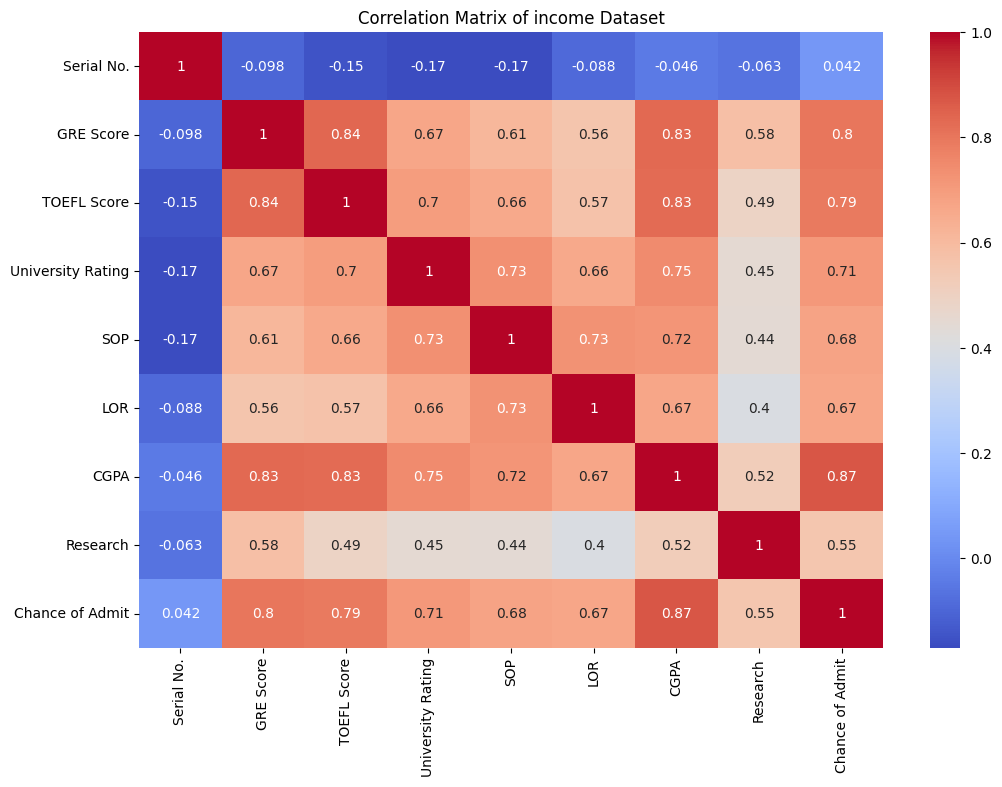

In [166]:
plt.figure(figsize=(12, 8))
corr = data_Admission.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of income Dataset')
plt.show()

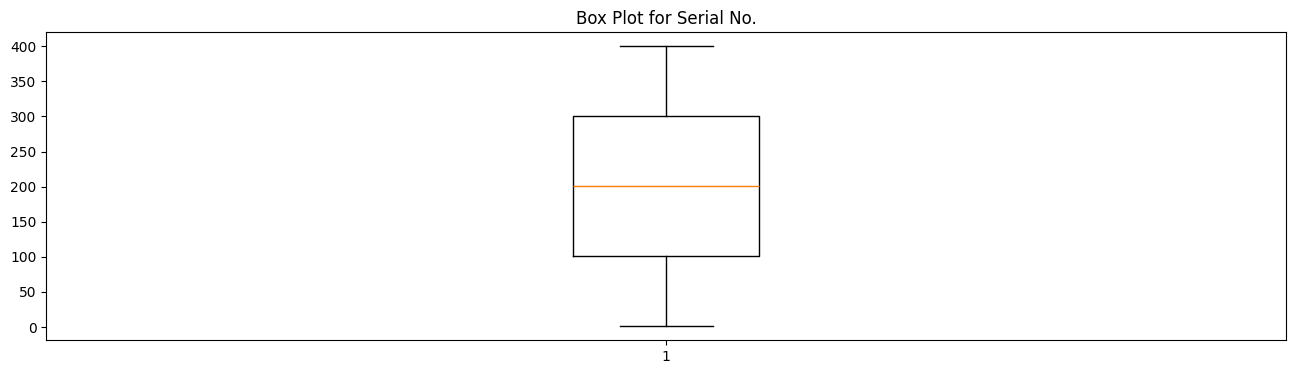

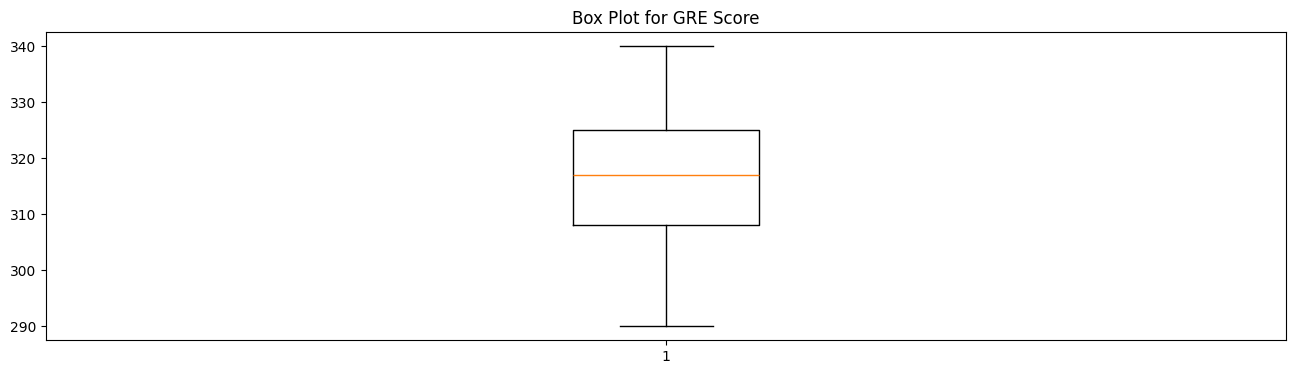

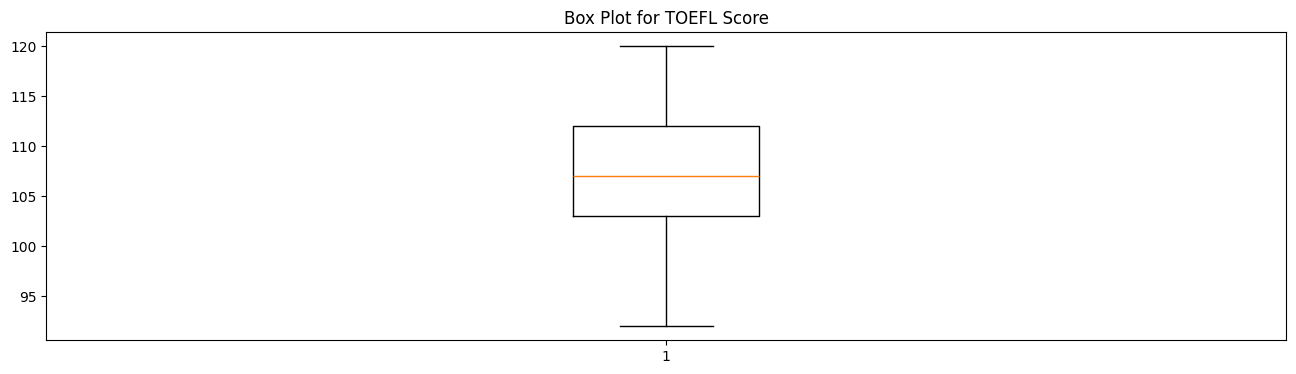

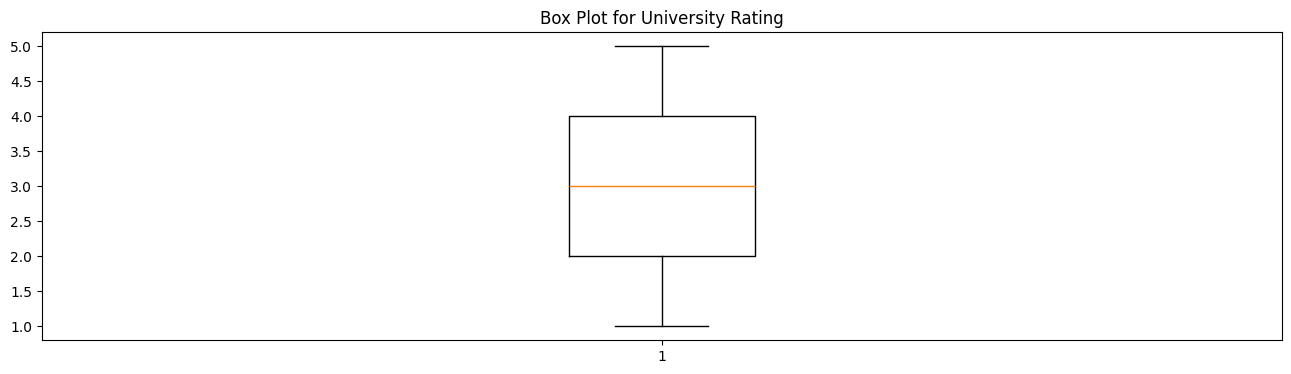

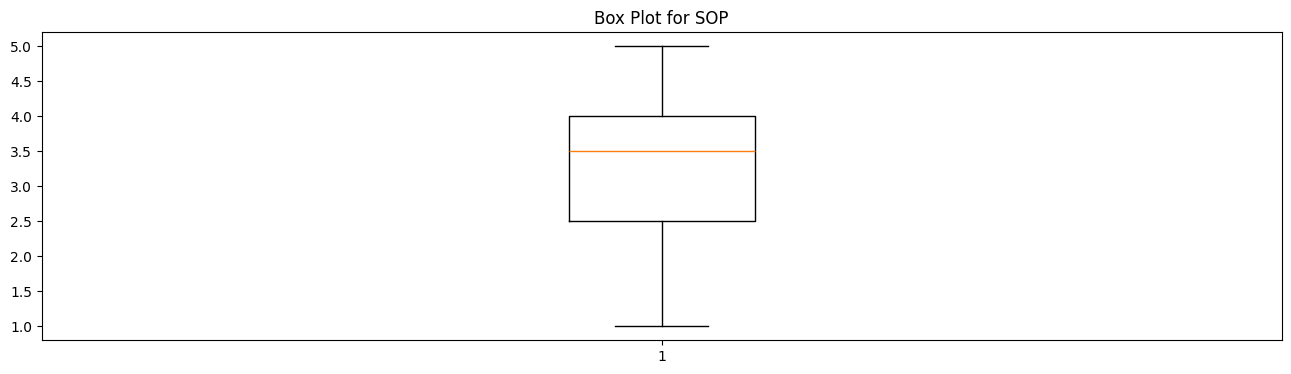

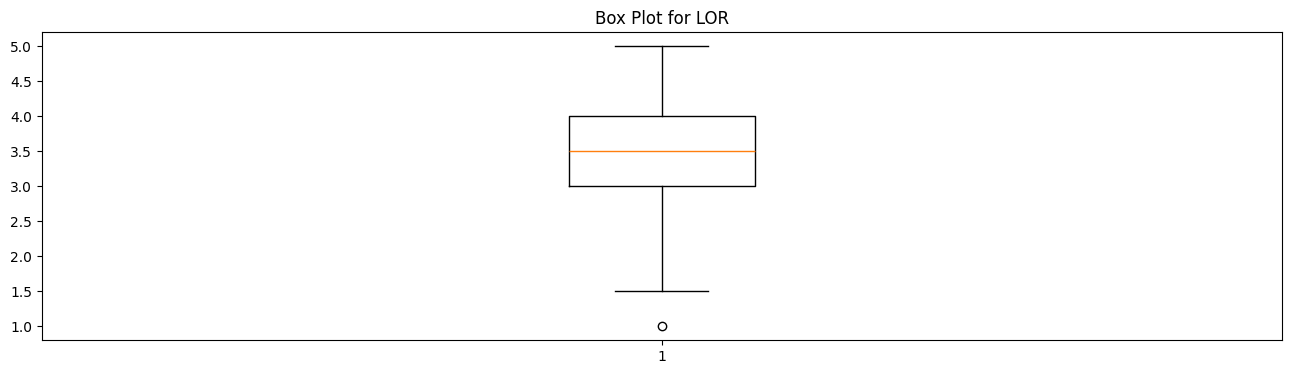

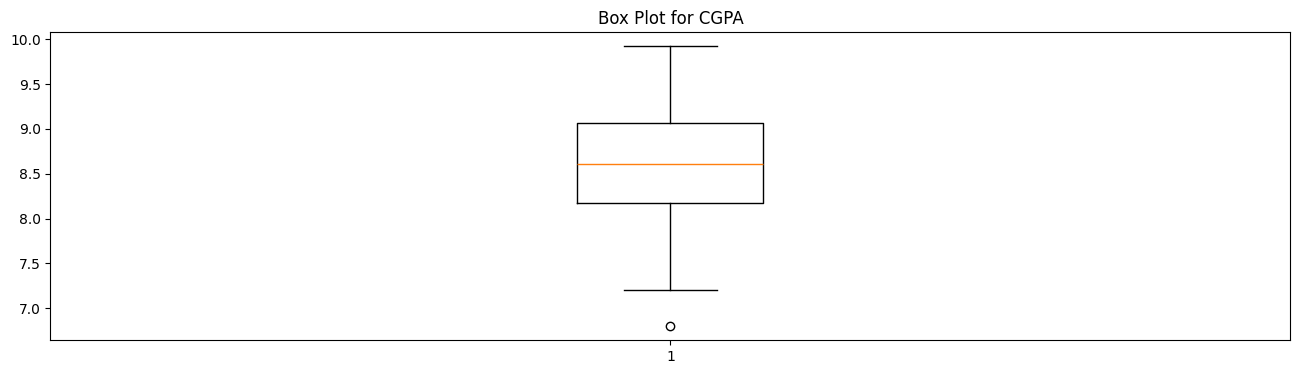

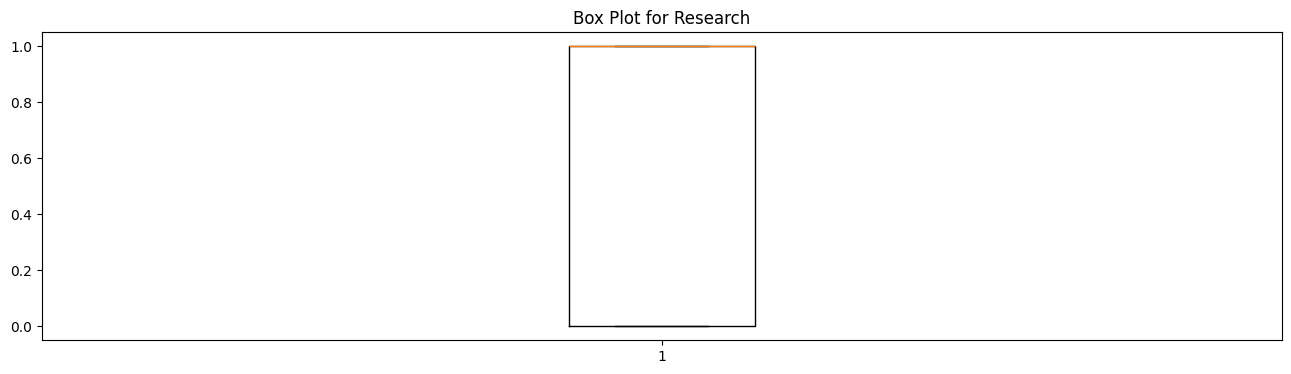

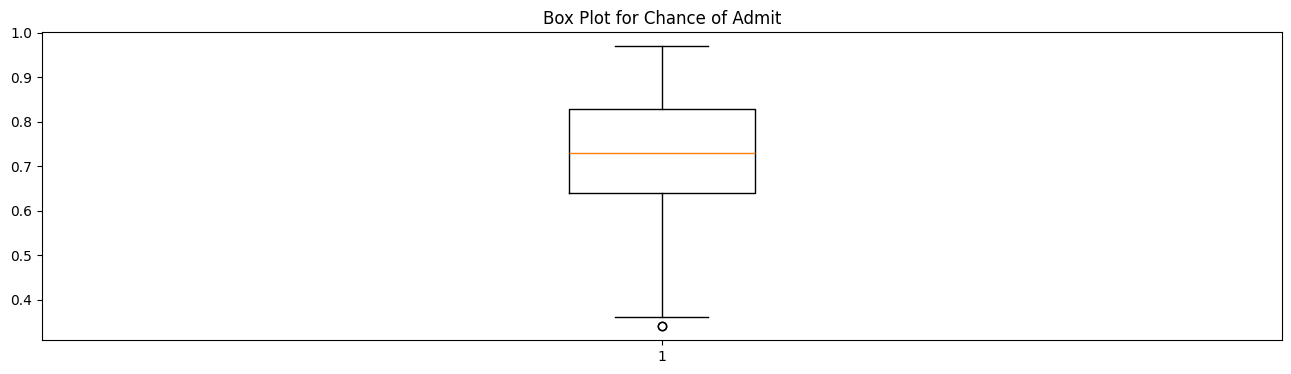

In [167]:
for col in data_Admission :
 plt.figure(figsize=(16,4))
 plt.boxplot(data_Admission[col])
 plt.title(f"Box Plot for {col}")
 plt.show()

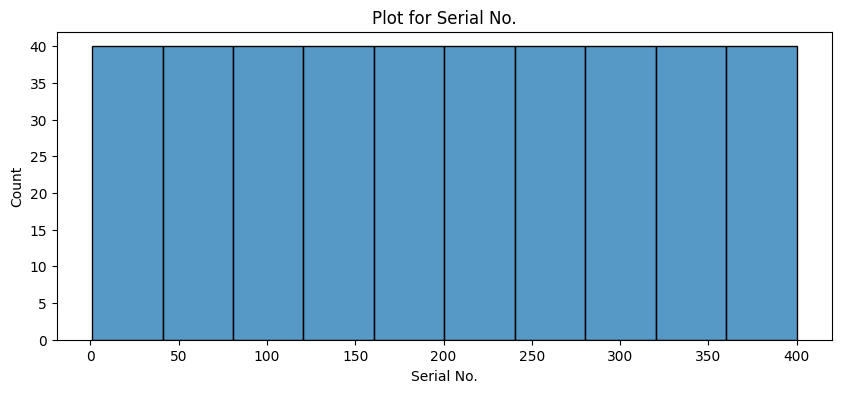

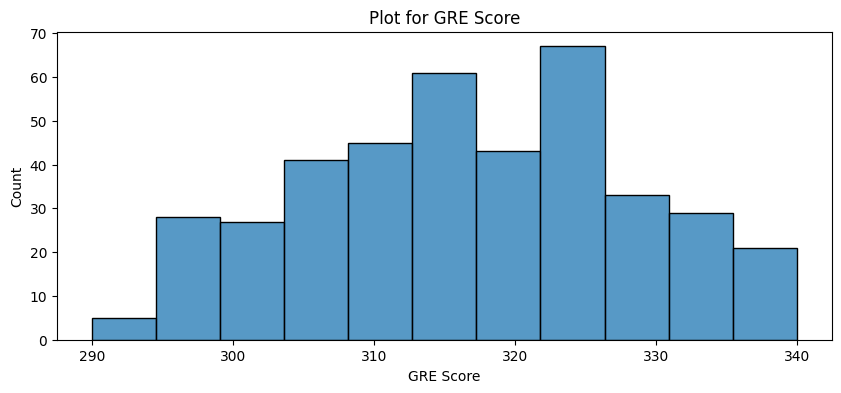

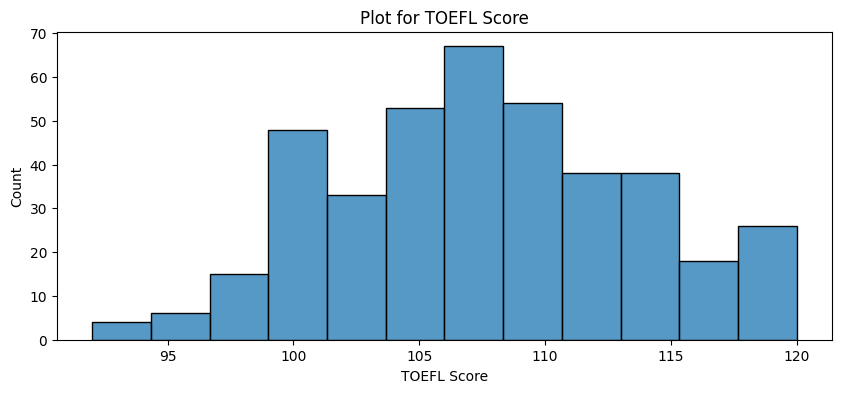

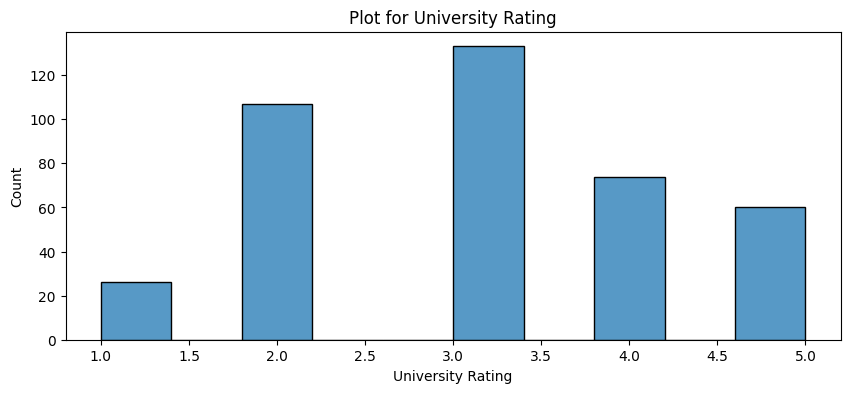

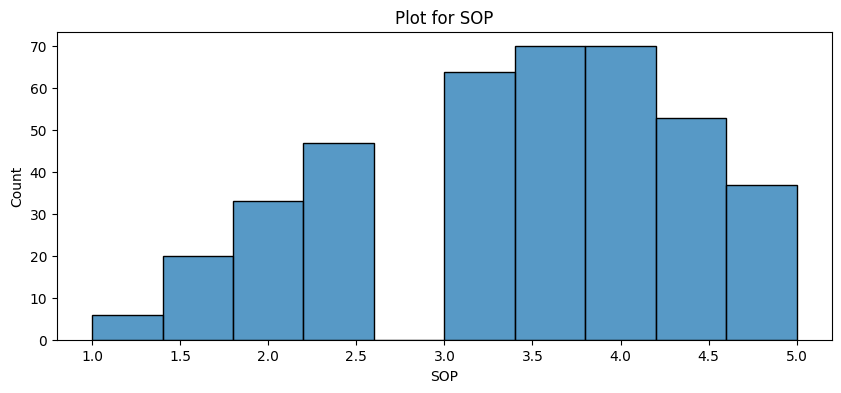

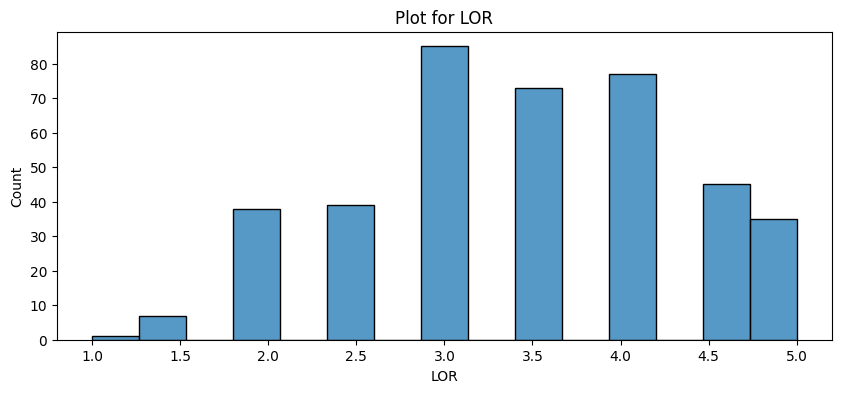

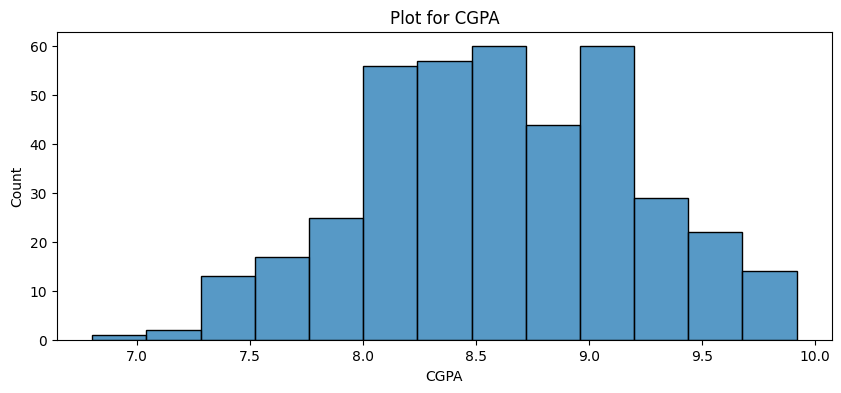

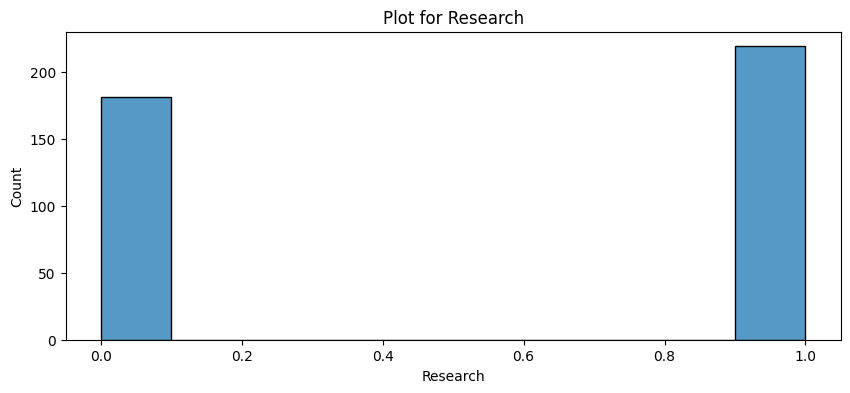

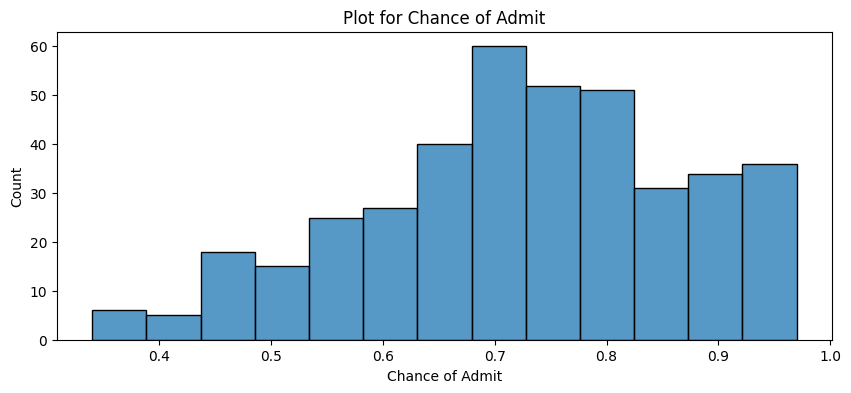

In [168]:
for col in data_Admission :
  plt.figure(figsize=(10,4))
  sns.histplot(data_Admission[col])
  plt.title(f"Plot for {col}")
  plt.show()


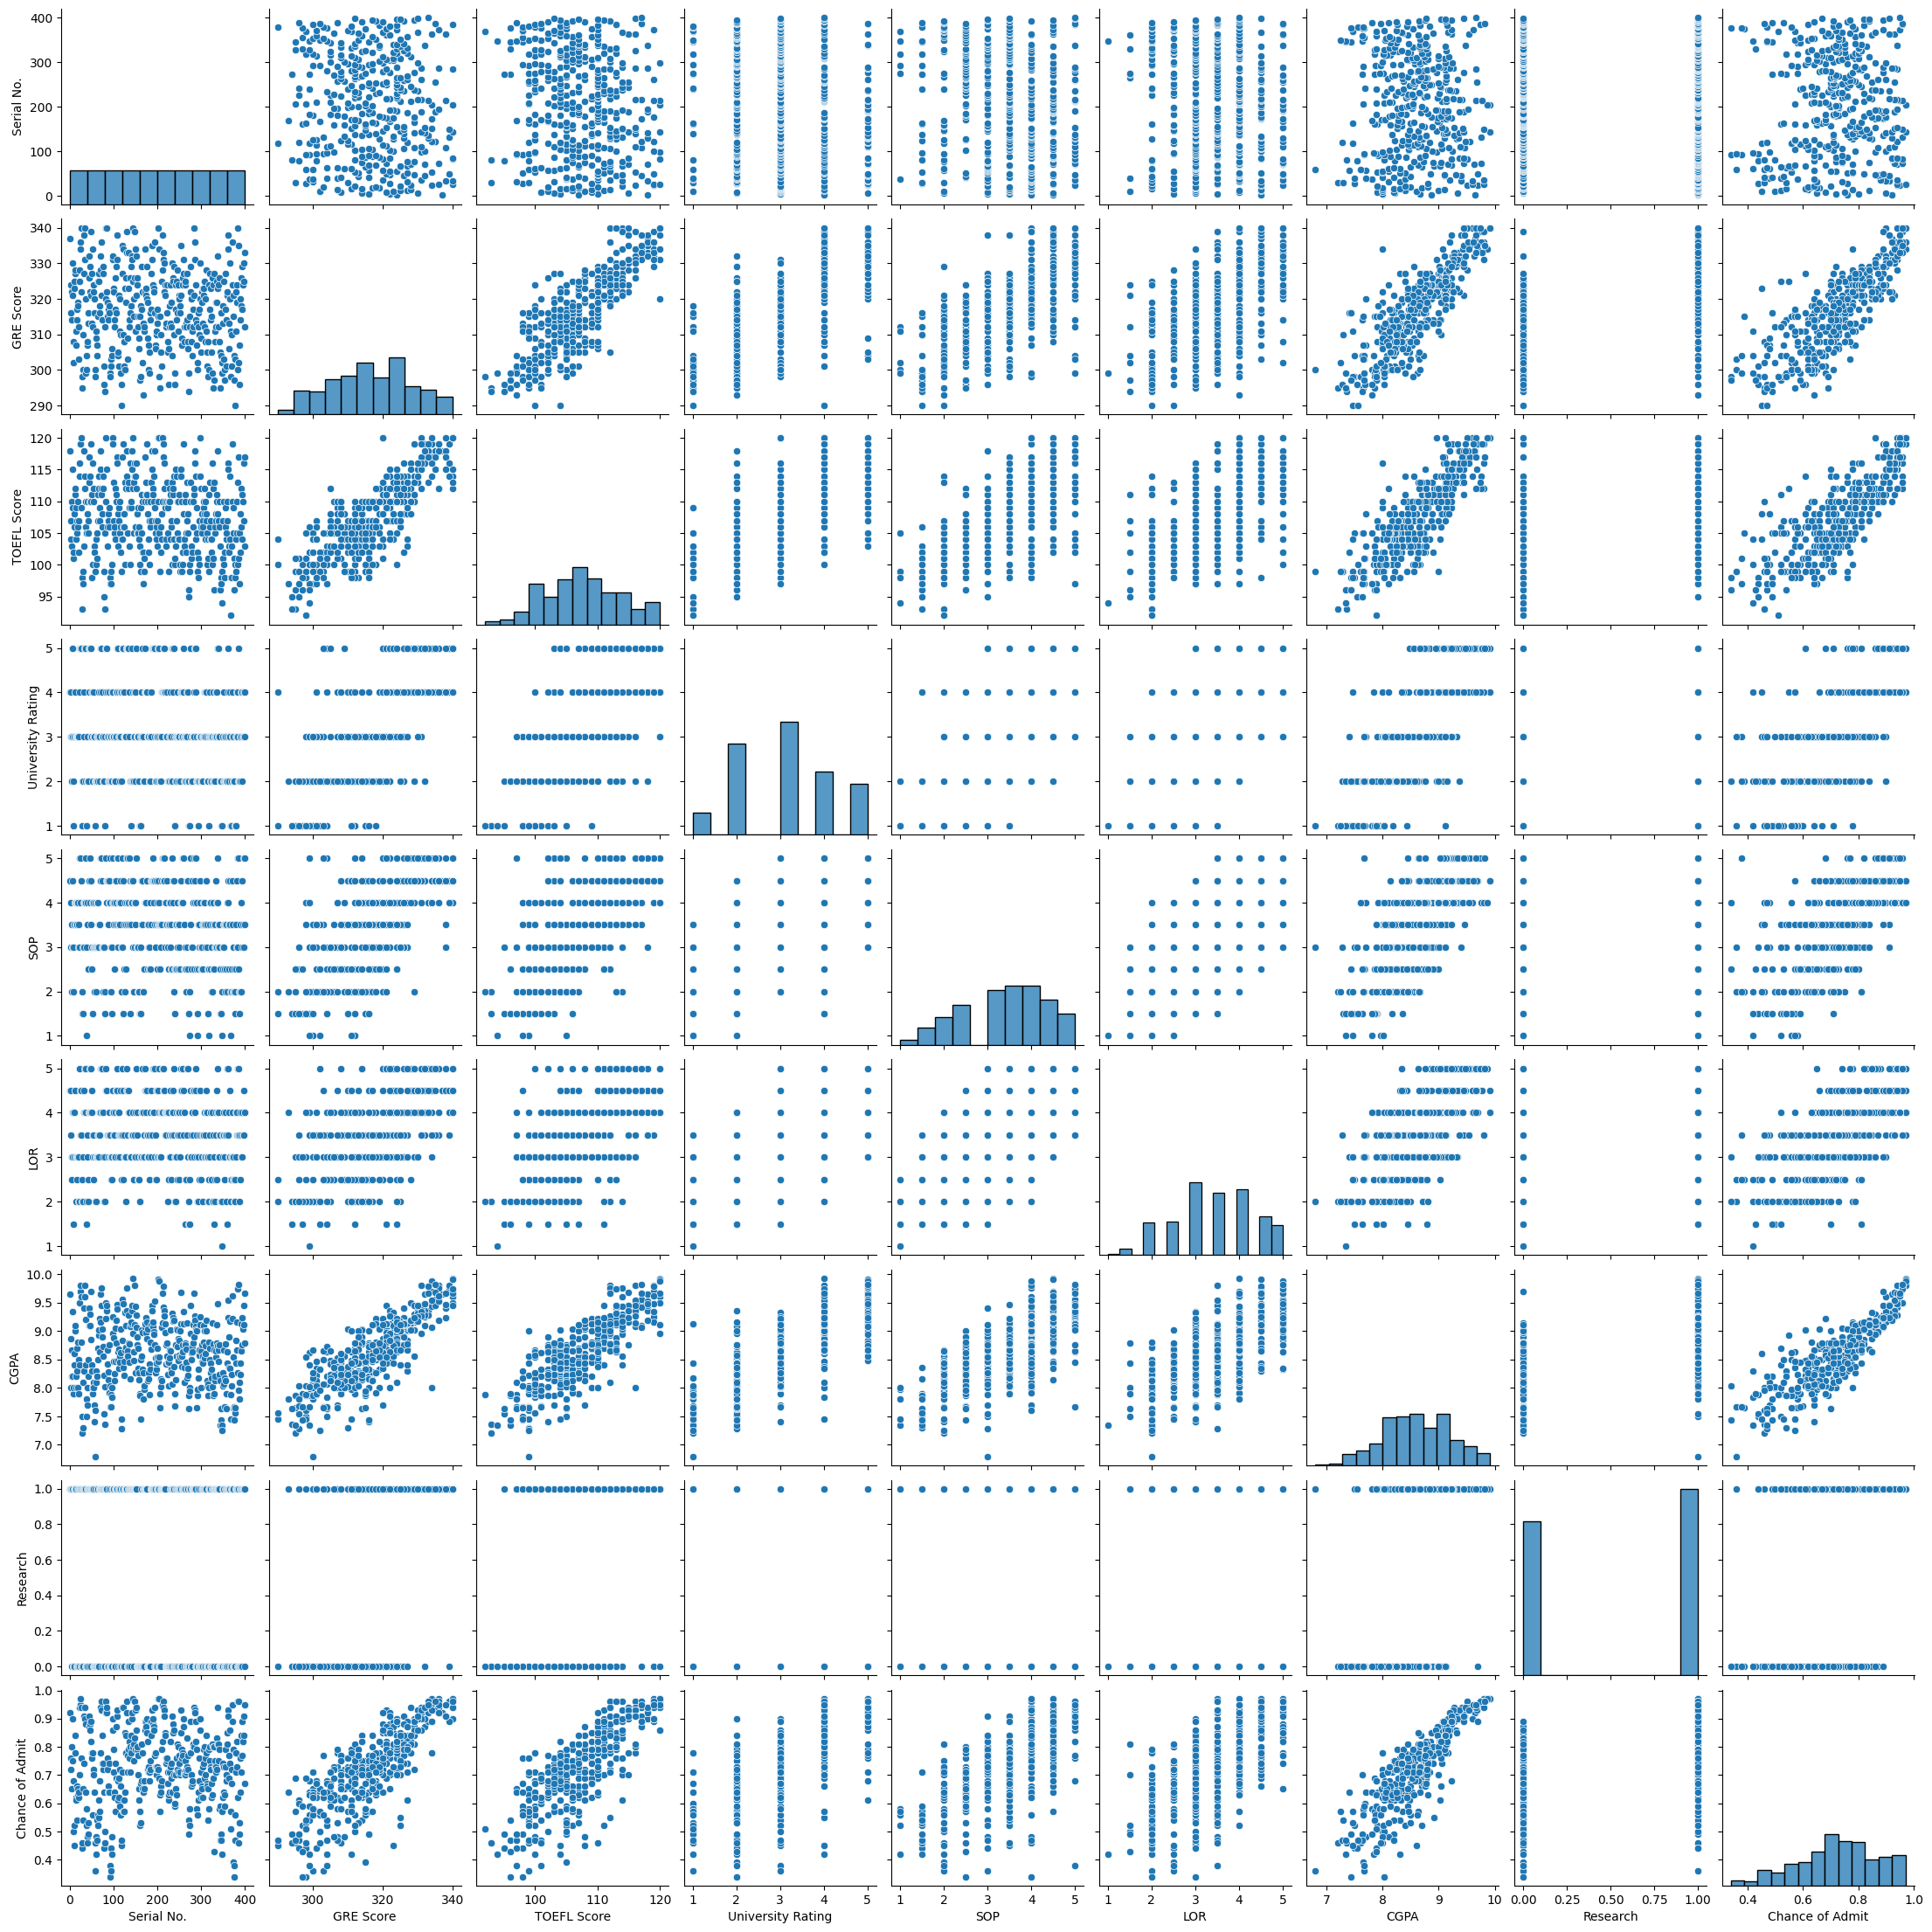

In [169]:
sns.pairplot(data_Admission)
plt.show()

In [170]:
for x in data_Admission:
  print(data_Admission[x].value_counts())

Serial No.
384    1
383    1
382    1
381    1
380    1
      ..
5      1
4      1
3      1
2      1
1      1
Name: count, Length: 400, dtype: int64
GRE Score
324    19
312    19
322    14
314    14
316    14
325    13
321    13
327    12
311    12
320    12
317    12
308    11
313    11
326    11
323    10
315    10
319     9
300     9
329     9
318     9
304     8
307     8
331     8
340     8
305     8
301     8
310     8
299     8
334     7
298     7
309     6
330     6
328     6
306     6
332     6
296     5
302     5
336     5
303     5
338     4
295     4
333     4
297     4
335     4
339     3
290     2
294     2
337     1
293     1
Name: count, dtype: int64
TOEFL Score
110    37
105    28
107    26
104    25
106    24
112    21
100    19
99     18
108    17
109    17
111    17
102    17
103    16
114    15
113    14
101    11
116    11
115     9
118     9
119     9
98      9
120     8
117     7
97      6
96      4
93      2
95      2
94      1
92      1
Name: count, dtype: int

In [171]:
data_Admission["Chance of Admit"] = data_Admission["Chance of Admit"].apply(lambda x: 1 if x > 0.75 else 0)

In [172]:
data_Admission["Chance of Admit"].value_counts()


,count
Chance of Admit,
0,228
1,172


In [173]:
from sklearn.model_selection import train_test_split

x = data_Admission.drop("Chance of Admit", axis=1)
y = data_Admission["Chance of Admit"]

x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.3,random_state=42)

In [174]:
from sklearn.tree import DecisionTreeClassifier


model = DecisionTreeClassifier()
model.fit(x_train, y_train)


DecisionTreeClassifier()

In [175]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy:", accuracy)


Decision Tree Accuracy: 0.8916666666666667


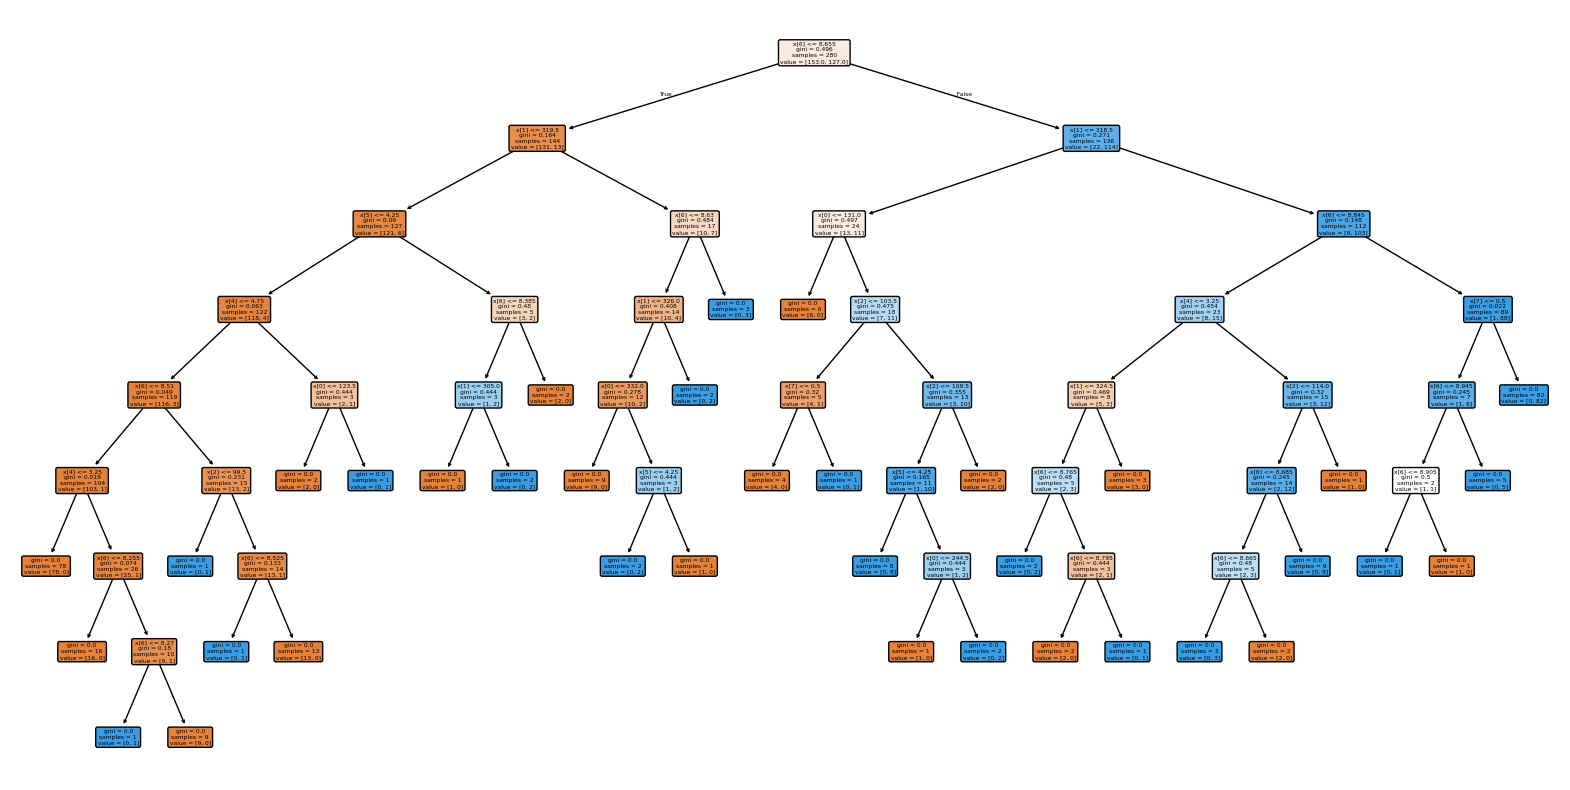

In [176]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(
    model,
    filled=True,
    rounded=True
)
plt.show()

In [177]:
data_Admission_linear["Chance of Admit"].value_counts()

,count
Chance of Admit,
0.64,17
0.71,16
0.72,15
0.73,13
0.94,12
0.70,12
0.78,12
0.76,12
0.79,12


In [178]:
x = data_Admission_linear.drop("Chance of Admit", axis=1)
y = data_Admission_linear["Chance of Admit"]

x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.4,random_state=42)

In [179]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [184]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

model = DecisionTreeRegressor()

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Training Score:", model.score(x_train, y_train))
print("R2:", model.score(x_test, y_test))
print("MSE =", mean_squared_error(y_test, y_pred))
print("RMSE =", np.sqrt(mean_squared_error(y_test, y_pred)))


Training Score: 1.0
R2: 0.5353064166778609
MSE = 0.009905
RMSE = 0.0995238664843765


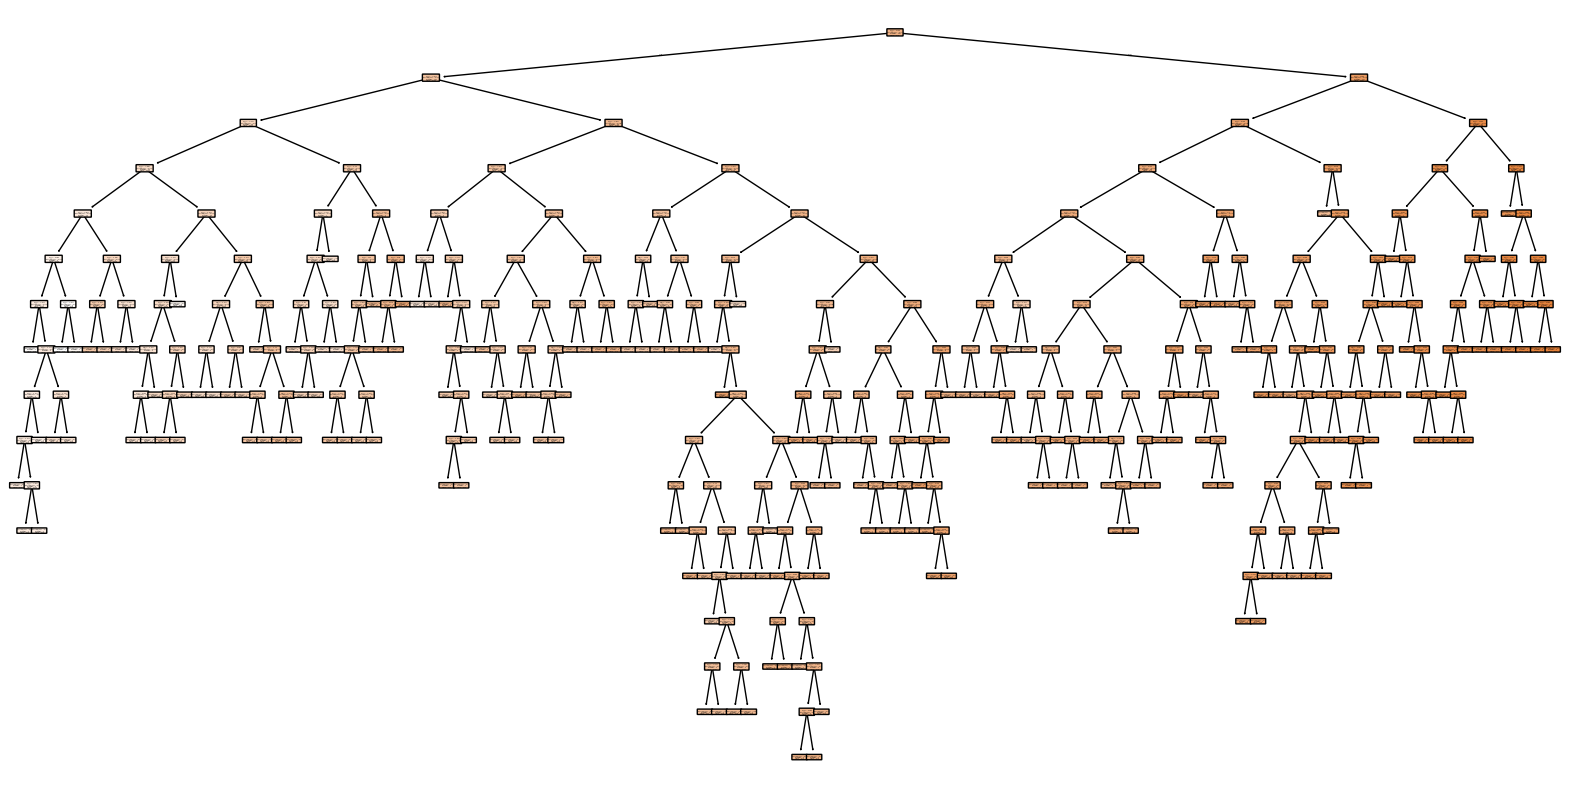

In [181]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(
    model,
    filled=True,
    rounded=True
)
plt.show()

In [182]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, 10, 12 ,14 ,15],
    'min_samples_split': [2, 5, 10, 15,20,25],
    'min_samples_leaf': [1, 2, 5 ,7,10,12]
}

dt = DecisionTreeRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)

print("Best Parameters:", grid_search.best_params_)
print("Training Score:", best_model.score(x_train, y_train))


Best Parameters: {'max_depth': 5, 'min_samples_leaf': 12, 'min_samples_split': 2}
Training Score: 0.832602805451116


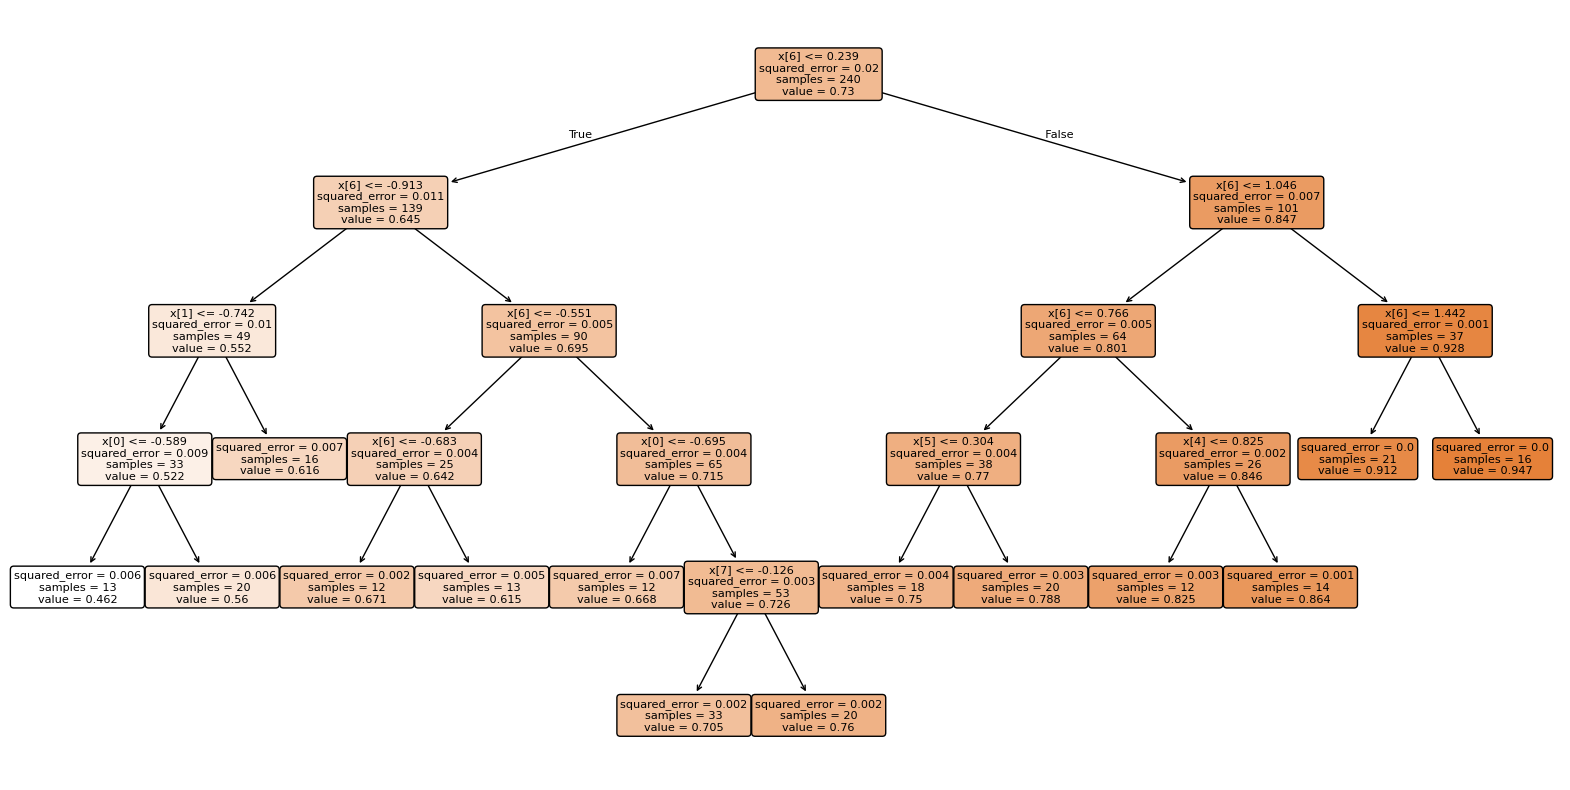

In [183]:
plt.figure(figsize=(20,10))

plot_tree(
    best_model,
    filled=True,
    rounded=True
)

plt.show()